In [2]:
from scipy.stats import gaussian_kde
import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np
import json
import bilby

plt.style.use("MATPLOTLIB_RCPARAMS.sty")
mpl.rcParams['text.latex.preamble'] = r'\usepackage{amsmath}'

Run 2: $\theta_{JN} = \pi/2$

Run 3:  $\theta_{JN} = \pi/3$

Run 4: $\theta_{JN} = 0$

In [3]:
with open('PE/run2/NRSur/outdir/final_result/NRSur_data0_10-0_analysis_ET_result.json') as json_file:
    run2_full = json.load(json_file)

with open('PE/run2/dom_off/outdir/final_result/dom_off_data0_10-0_analysis_ET_result.json') as json_file:
    run2_domoff = json.load(json_file)

with open('PE/run2/subdom_off/outdir/final_result/subdom_off_data0_10-0_analysis_ET_result.json') as json_file:
    run2_suboff = json.load(json_file)


with open('PE/run3/NRSur/outdir/final_result/NRSur_data0_10-0_analysis_ET_result.json') as json_file:
    run3_full = json.load(json_file)

with open('PE/run3/dom_off/outdir/final_result/dom_off_data0_10-0_analysis_ET_result.json') as json_file:
    run3_domoff = json.load(json_file)

with open('PE/run3/subdom_off/outdir/final_result/subdom_off_data0_10-0_analysis_ET_result.json') as json_file:
    run3_suboff = json.load(json_file)


with open('PE/run4/NRSur/outdir/final_result/NRSur_data0_10-0_analysis_ET_result.json') as json_file:
    run4_full = json.load(json_file)

with open('PE/run4/dom_off/outdir/final_result/dom_off_data0_10-0_analysis_ET_result.json') as json_file:
    run4_domoff = json.load(json_file)

with open('PE/run4/subdom_off/outdir/final_result/subdom_off_data0_10-0_analysis_ET_result.json') as json_file:
    run4_suboff = json.load(json_file)

In [6]:
M = 90
q = 1
chirp_mass = M * ( q/(1+q)**2 )**(3/5)
print('chirp mass:', chirp_mass)

chirp mass: 39.17477534832558


In [4]:
plt.rcParams["figure.figsize"] = (8, 6)
plt.rcParams["xtick.labelsize"] = 23
plt.rcParams["ytick.labelsize"] = 23
plt.rcParams["axes.labelsize"] = 23
plt.rcParams["legend.fontsize"] = 23
plt.rcParams["font.size"] = 23

In [31]:
run2_full['posterior']['content'].keys()

dict_keys(['chirp_mass', 'mass_ratio', 'a_1', 'a_2', 'tilt_1', 'tilt_2', 'phi_12', 'phi_jl', 'dec', 'ra', 'theta_jn', 'psi', 'phase', 'geocent_time', 'luminosity_distance', 'log_likelihood', 'log_prior', 'reference_frequency', 'waveform_approximant', 'minimum_frequency', 'total_mass', 'mass_1', 'mass_2', 'ET1_log_likelihood', 'ET1_matched_filter_snr', 'ET1_optimal_snr', 'symmetric_mass_ratio', 'iota', 'spin_1x', 'spin_1y', 'spin_1z', 'spin_2x', 'spin_2y', 'spin_2z', 'phi_1', 'phi_2', 'chi_eff', 'chi_1_in_plane', 'chi_2_in_plane', 'chi_p', 'cos_tilt_1', 'cos_tilt_2', 'redshift', 'comoving_distance', 'mass_1_source', 'mass_2_source', 'chirp_mass_source', 'total_mass_source'])

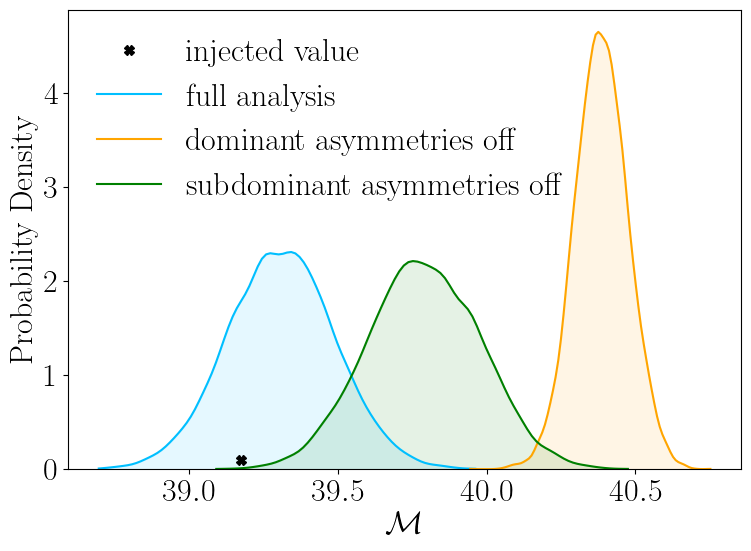

In [32]:
plt.figure(figsize=(8,6))  

plt.plot(chirp_mass, 0.1, 'X', color='black', markersize=7, label='injected value')

samples = run2_full['posterior']['content']['chirp_mass']
label = 'full analysis'
color = 'deepskyblue'
rho_p_smoothed = gaussian_kde(samples)
h, b, o = plt.hist(samples, bins=90, density=True, histtype='step', stacked=True, fill=False, linewidth=0, color=color)
hsmoothed = rho_p_smoothed(b)*len(samples)*(b[1]-b[0])
hsmoothed = hsmoothed*max(h)/max(hsmoothed) # scale to normalise kde
plt.plot(b, hsmoothed, color=color, label=label)
plt.fill_between(b, hsmoothed, where=(0 < b)&(b < max(samples)), color=color, alpha=0.1)

samples = run2_domoff['posterior']['content']['chirp_mass']
label = 'dominant asymmetries off'
color = 'orange'
rho_p_smoothed = gaussian_kde(samples)
h, b, o = plt.hist(samples, bins=90, density=True, histtype='step', stacked=True, fill=False, linewidth=0, color=color)
hsmoothed = rho_p_smoothed(b)*len(samples)*(b[1]-b[0])
hsmoothed = hsmoothed*max(h)/max(hsmoothed) # scale to normalise kde
plt.plot(b, hsmoothed, color=color, label=label)
plt.fill_between(b, hsmoothed, where=(0 < b)&(b < max(samples)), color=color, alpha=0.1)

samples = run2_suboff['posterior']['content']['chirp_mass']
label = 'subdominant asymmetries off'
color = 'green'
rho_p_smoothed = gaussian_kde(samples)
h, b, o = plt.hist(samples, bins=90, density=True, histtype='step', stacked=True, fill=False, linewidth=0, color=color)
hsmoothed = rho_p_smoothed(b)*len(samples)*(b[1]-b[0])
hsmoothed = hsmoothed*max(h)/max(hsmoothed) # scale to normalise kde
plt.plot(b, hsmoothed, color=color, label=label)
plt.fill_between(b, hsmoothed, where=(0 < b)&(b < max(samples)), color=color, alpha=0.1)

#plt.ylim(0,6.3)
plt.xlabel(r'$\mathcal{M}$')
plt.ylabel('Probability Density')
plt.grid(linewidth=0.0)
plt.tight_layout()
plt.legend(frameon=False, numpoints=1)
#lgd = plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', numpoints=1)
#plt.savefig('figures/chirp_mass.png')
plt.show()
plt.close()

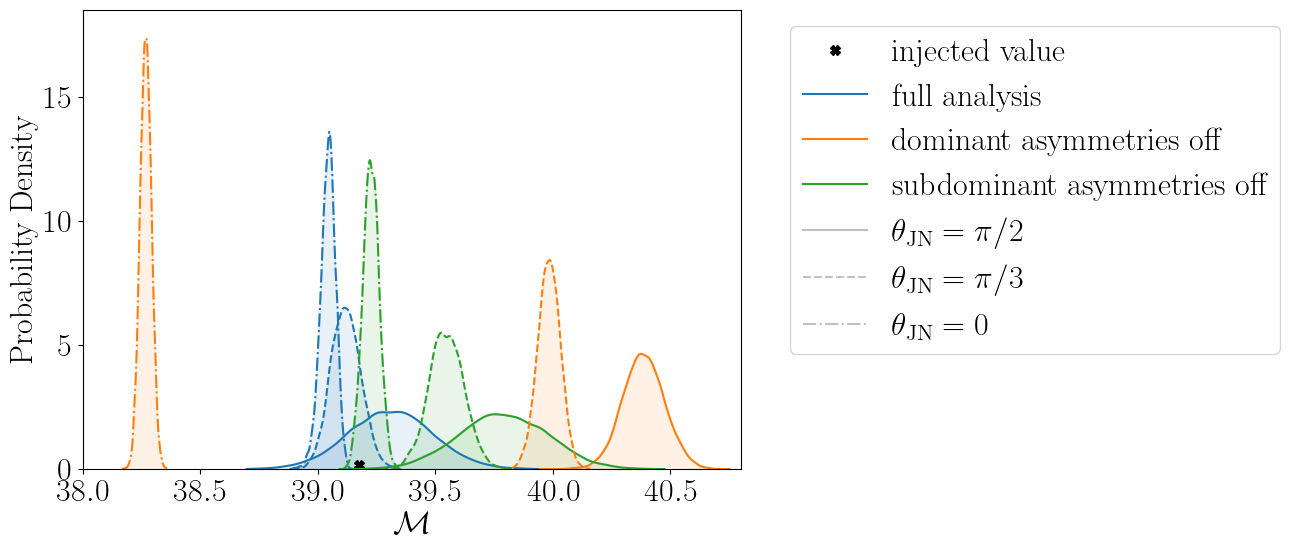

In [51]:
plt.figure(figsize=(8,6))  

plt.plot(chirp_mass, 0.15, 'X', color='black', markersize=7, label='injected value')

samples = run2_full['posterior']['content']['chirp_mass']
label = 'full analysis'
color = 'tab:blue'
rho_p_smoothed = gaussian_kde(samples)
h, b, o = plt.hist(samples, bins=90, density=True, histtype='step', stacked=True, fill=False, linewidth=0, color=color)
hsmoothed = rho_p_smoothed(b)*len(samples)*(b[1]-b[0])
hsmoothed = hsmoothed*max(h)/max(hsmoothed) # scale to normalise kde
plt.plot(b, hsmoothed, color=color, label=label)
plt.fill_between(b, hsmoothed, where=(0 < b)&(b < max(samples)), color=color, alpha=0.1)

samples = run2_domoff['posterior']['content']['chirp_mass']
label = 'dominant asymmetries off'
color = 'tab:orange'
rho_p_smoothed = gaussian_kde(samples)
h, b, o = plt.hist(samples, bins=90, density=True, histtype='step', stacked=True, fill=False, linewidth=0, color=color)
hsmoothed = rho_p_smoothed(b)*len(samples)*(b[1]-b[0])
hsmoothed = hsmoothed*max(h)/max(hsmoothed) # scale to normalise kde
plt.plot(b, hsmoothed, color=color, label=label)
plt.fill_between(b, hsmoothed, where=(0 < b)&(b < max(samples)), color=color, alpha=0.1)

samples = run2_suboff['posterior']['content']['chirp_mass']
label = 'subdominant asymmetries off'
color = 'tab:green'
rho_p_smoothed = gaussian_kde(samples)
h, b, o = plt.hist(samples, bins=90, density=True, histtype='step', stacked=True, fill=False, linewidth=0, color=color)
hsmoothed = rho_p_smoothed(b)*len(samples)*(b[1]-b[0])
hsmoothed = hsmoothed*max(h)/max(hsmoothed) # scale to normalise kde
plt.plot(b, hsmoothed, color=color, label=label)
plt.fill_between(b, hsmoothed, where=(0 < b)&(b < max(samples)), color=color, alpha=0.1)


samples = run3_full['posterior']['content']['chirp_mass']
color = 'tab:blue'
rho_p_smoothed = gaussian_kde(samples)
h, b, o = plt.hist(samples, bins=90, density=True, histtype='step', stacked=True, fill=False, linewidth=0, color=color)
hsmoothed = rho_p_smoothed(b)*len(samples)*(b[1]-b[0])
hsmoothed = hsmoothed*max(h)/max(hsmoothed) # scale to normalise kde
plt.plot(b, hsmoothed, '--', color=color)
plt.fill_between(b, hsmoothed, where=(0 < b)&(b < max(samples)), color=color, alpha=0.1)

samples = run3_domoff['posterior']['content']['chirp_mass']
label = 'dominant asymmetries off'
color = 'tab:orange'
rho_p_smoothed = gaussian_kde(samples)
h, b, o = plt.hist(samples, bins=90, density=True, histtype='step', stacked=True, fill=False, linewidth=0, color=color)
hsmoothed = rho_p_smoothed(b)*len(samples)*(b[1]-b[0])
hsmoothed = hsmoothed*max(h)/max(hsmoothed) # scale to normalise kde
plt.plot(b, hsmoothed, '--', color=color)
plt.fill_between(b, hsmoothed, where=(0 < b)&(b < max(samples)), color=color, alpha=0.1)

samples = run3_suboff['posterior']['content']['chirp_mass']
color = 'tab:green'
rho_p_smoothed = gaussian_kde(samples)
h, b, o = plt.hist(samples, bins=90, density=True, histtype='step', stacked=True, fill=False, linewidth=0, color=color)
hsmoothed = rho_p_smoothed(b)*len(samples)*(b[1]-b[0])
hsmoothed = hsmoothed*max(h)/max(hsmoothed) # scale to normalise kde
plt.plot(b, hsmoothed, '--', color=color)
plt.fill_between(b, hsmoothed, where=(0 < b)&(b < max(samples)), color=color, alpha=0.1)


samples = run4_full['posterior']['content']['chirp_mass']
color = 'tab:blue'
rho_p_smoothed = gaussian_kde(samples)
h, b, o = plt.hist(samples, bins=90, density=True, histtype='step', stacked=True, fill=False, linewidth=0, color=color)
hsmoothed = rho_p_smoothed(b)*len(samples)*(b[1]-b[0])
hsmoothed = hsmoothed*max(h)/max(hsmoothed) # scale to normalise kde
plt.plot(b, hsmoothed, '-.', color=color)
plt.fill_between(b, hsmoothed, where=(0 < b)&(b < max(samples)), color=color, alpha=0.1)

samples = run4_domoff['posterior']['content']['chirp_mass']
label = 'dominant asymmetries off'
color = 'tab:orange'
rho_p_smoothed = gaussian_kde(samples)
h, b, o = plt.hist(samples, bins=90, density=True, histtype='step', stacked=True, fill=False, linewidth=0, color=color)
hsmoothed = rho_p_smoothed(b)*len(samples)*(b[1]-b[0])
hsmoothed = hsmoothed*max(h)/max(hsmoothed) # scale to normalise kde
plt.plot(b, hsmoothed, '-.', color=color)
plt.fill_between(b, hsmoothed, where=(0 < b)&(b < max(samples)), color=color, alpha=0.1)

samples = run4_suboff['posterior']['content']['chirp_mass']
color = 'tab:green'
rho_p_smoothed = gaussian_kde(samples)
h, b, o = plt.hist(samples, bins=90, density=True, histtype='step', stacked=True, fill=False, linewidth=0, color=color)
hsmoothed = rho_p_smoothed(b)*len(samples)*(b[1]-b[0])
hsmoothed = hsmoothed*max(h)/max(hsmoothed) # scale to normalise kde
plt.plot(b, hsmoothed, '-.', color=color)
plt.fill_between(b, hsmoothed, where=(0 < b)&(b < max(samples)), color=color, alpha=0.1)

plt.plot(0, -10, '-', color='silver', label=r'$\theta_{\rm JN} = \pi/2$')
plt.plot(0, -10, '--', color='silver', label=r'$\theta_{\rm JN} = \pi/3$')
plt.plot(0, -10, '-.', color='silver', label=r'$\theta_{\rm JN} = 0$')

plt.xlim(38, 40.8)
plt.ylim(0, 18.5)
plt.xlabel(r'$\mathcal{M}$')
plt.ylabel('Probability Density')
plt.grid(linewidth=0.0)
plt.tight_layout()
#plt.legend(frameon=False, numpoints=1)
lgd = plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', numpoints=1)
plt.savefig('figures/chirp_mass_comparison.png', bbox_extra_artists=(lgd,), bbox_inches='tight')
plt.show()
plt.close()

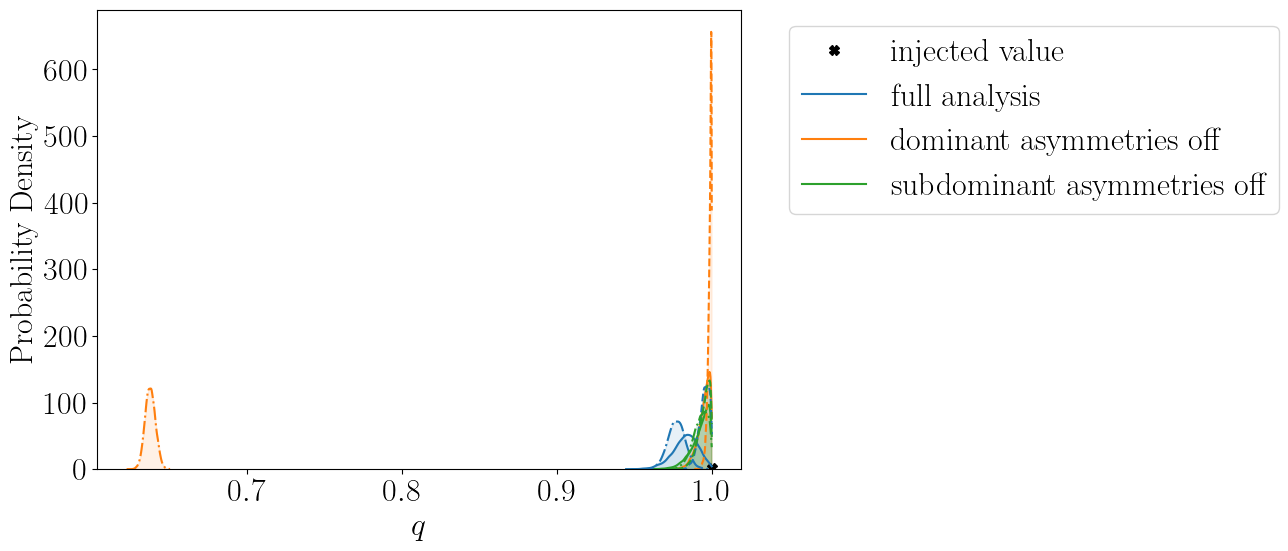

In [52]:
plt.figure(figsize=(8,6))  

plt.plot(1, 2, 'X', color='black', markersize=7, label='injected value')

samples = run2_full['posterior']['content']['mass_ratio']
label = 'full analysis'
color = 'tab:blue'
rho_p_smoothed = gaussian_kde(samples)
h, b, o = plt.hist(samples, bins=90, density=True, histtype='step', stacked=True, fill=False, linewidth=0, color=color)
hsmoothed = rho_p_smoothed(b)*len(samples)*(b[1]-b[0])
hsmoothed = hsmoothed*max(h)/max(hsmoothed) # scale to normalise kde
plt.plot(b, hsmoothed, color=color, label=label)
plt.fill_between(b, hsmoothed, where=(0 < b)&(b < max(samples)), color=color, alpha=0.1)

samples = run2_domoff['posterior']['content']['mass_ratio']
label = 'dominant asymmetries off'
color = 'tab:orange'
rho_p_smoothed = gaussian_kde(samples)
h, b, o = plt.hist(samples, bins=90, density=True, histtype='step', stacked=True, fill=False, linewidth=0, color=color)
hsmoothed = rho_p_smoothed(b)*len(samples)*(b[1]-b[0])
hsmoothed = hsmoothed*max(h)/max(hsmoothed) # scale to normalise kde
plt.plot(b, hsmoothed, color=color, label=label)
plt.fill_between(b, hsmoothed, where=(0 < b)&(b < max(samples)), color=color, alpha=0.1)


samples = run2_suboff['posterior']['content']['mass_ratio']
label = 'subdominant asymmetries off'
color = 'tab:green'
rho_p_smoothed = gaussian_kde(samples)
h, b, o = plt.hist(samples, bins=90, density=True, histtype='step', stacked=True, fill=False, linewidth=0, color=color)
hsmoothed = rho_p_smoothed(b)*len(samples)*(b[1]-b[0])
hsmoothed = hsmoothed*max(h)/max(hsmoothed) # scale to normalise kde
plt.plot(b, hsmoothed, color=color, label=label)
plt.fill_between(b, hsmoothed, where=(0 < b)&(b < max(samples)), color=color, alpha=0.1)


samples = run3_full['posterior']['content']['mass_ratio']
color = 'tab:blue'
rho_p_smoothed = gaussian_kde(samples)
h, b, o = plt.hist(samples, bins=90, density=True, histtype='step', stacked=True, fill=False, linewidth=0, color=color)
hsmoothed = rho_p_smoothed(b)*len(samples)*(b[1]-b[0])
hsmoothed = hsmoothed*max(h)/max(hsmoothed) # scale to normalise kde
plt.plot(b, hsmoothed, '--', color=color)
plt.fill_between(b, hsmoothed, where=(0 < b)&(b < max(samples)), color=color, alpha=0.1)

samples = run3_domoff['posterior']['content']['mass_ratio']
label = 'dominant asymmetries off'
color = 'tab:orange'
rho_p_smoothed = gaussian_kde(samples)
h, b, o = plt.hist(samples, bins=90, density=True, histtype='step', stacked=True, fill=False, linewidth=0, color=color)
hsmoothed = rho_p_smoothed(b)*len(samples)*(b[1]-b[0])
hsmoothed = hsmoothed*max(h)/max(hsmoothed) # scale to normalise kde
plt.plot(b, hsmoothed, '--', color=color)
plt.fill_between(b, hsmoothed, where=(0 < b)&(b < max(samples)), color=color, alpha=0.1)

samples = run3_suboff['posterior']['content']['mass_ratio']
color = 'tab:green'
rho_p_smoothed = gaussian_kde(samples)
h, b, o = plt.hist(samples, bins=90, density=True, histtype='step', stacked=True, fill=False, linewidth=0, color=color)
hsmoothed = rho_p_smoothed(b)*len(samples)*(b[1]-b[0])
hsmoothed = hsmoothed*max(h)/max(hsmoothed) # scale to normalise kde
plt.plot(b, hsmoothed, '--', color=color)
plt.fill_between(b, hsmoothed, where=(0 < b)&(b < max(samples)), color=color, alpha=0.1)


samples = run4_full['posterior']['content']['mass_ratio']
color = 'tab:blue'
rho_p_smoothed = gaussian_kde(samples)
h, b, o = plt.hist(samples, bins=90, density=True, histtype='step', stacked=True, fill=False, linewidth=0, color=color)
hsmoothed = rho_p_smoothed(b)*len(samples)*(b[1]-b[0])
hsmoothed = hsmoothed*max(h)/max(hsmoothed) # scale to normalise kde
plt.plot(b, hsmoothed, '-.', color=color)
plt.fill_between(b, hsmoothed, where=(0 < b)&(b < max(samples)), color=color, alpha=0.1)

samples = run4_domoff['posterior']['content']['mass_ratio']
label = 'dominant asymmetries off'
color = 'tab:orange'
rho_p_smoothed = gaussian_kde(samples)
h, b, o = plt.hist(samples, bins=90, density=True, histtype='step', stacked=True, fill=False, linewidth=0, color=color)
hsmoothed = rho_p_smoothed(b)*len(samples)*(b[1]-b[0])
hsmoothed = hsmoothed*max(h)/max(hsmoothed) # scale to normalise kde
plt.plot(b, hsmoothed, '-.', color=color)
plt.fill_between(b, hsmoothed, where=(0 < b)&(b < max(samples)), color=color, alpha=0.1)

samples = run4_suboff['posterior']['content']['mass_ratio']
color = 'tab:green'
rho_p_smoothed = gaussian_kde(samples)
h, b, o = plt.hist(samples, bins=90, density=True, histtype='step', stacked=True, fill=False, linewidth=0, color=color)
hsmoothed = rho_p_smoothed(b)*len(samples)*(b[1]-b[0])
hsmoothed = hsmoothed*max(h)/max(hsmoothed) # scale to normalise kde
plt.plot(b, hsmoothed, '-.', color=color)
plt.fill_between(b, hsmoothed, where=(0 < b)&(b < max(samples)), color=color, alpha=0.1)

#plt.plot(0, -10, '-', color='silver', label=r'$\theta_{\rm JN} = \pi/2$')
#plt.plot(0, -10, '--', color='silver', label=r'$\theta_{\rm JN} = \pi/3$')
#plt.plot(0, -10, '-.', color='silver', label=r'$\theta_{\rm JN} = 0$')

#plt.xlim(0.95, 1)
#plt.ylim(0, 145)
plt.xlabel(r'$q$')
plt.ylabel('Probability Density')
plt.grid(linewidth=0.0)
plt.tight_layout()
#plt.legend(frameon=False, numpoints=1)
lgd = plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', numpoints=1)
plt.savefig('figures/mass_ratio_comparison.png', bbox_extra_artists=(lgd,), bbox_inches='tight')
plt.show()
plt.close()

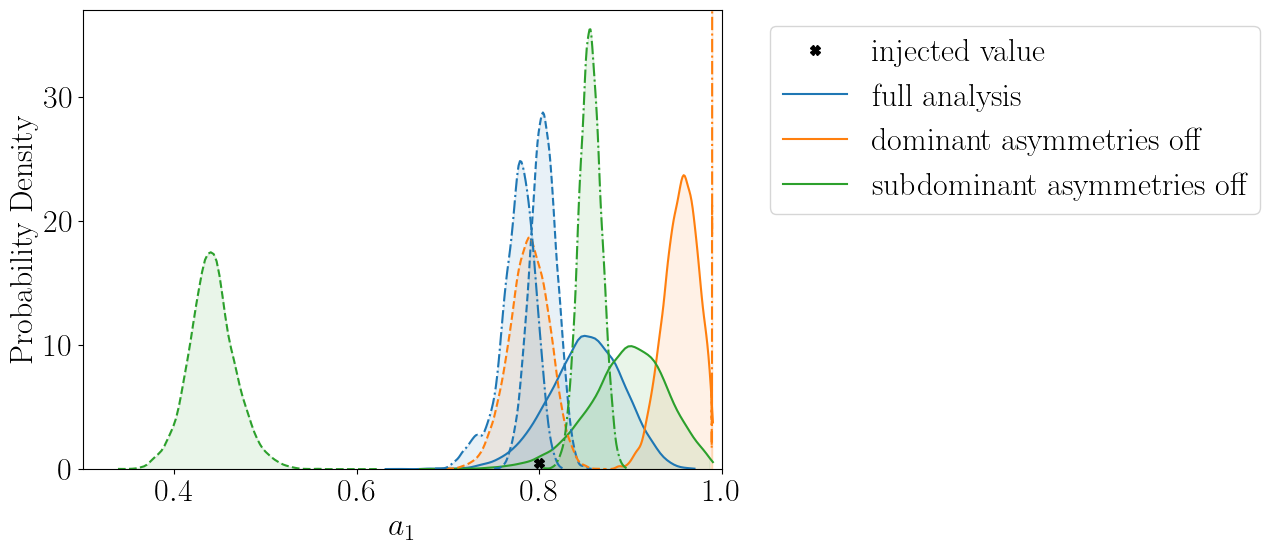

In [71]:
plt.figure(figsize=(8,6))  

plt.plot(0.8, 0.5, 'X', color='black', markersize=7, label='injected value')

samples = run2_full['posterior']['content']['a_1']
label = 'full analysis'
color = 'tab:blue'
rho_p_smoothed = gaussian_kde(samples)
h, b, o = plt.hist(samples, bins=90, density=True, histtype='step', stacked=True, fill=False, linewidth=0, color=color)
hsmoothed = rho_p_smoothed(b)*len(samples)*(b[1]-b[0])
hsmoothed = hsmoothed*max(h)/max(hsmoothed) # scale to normalise kde
plt.plot(b, hsmoothed, color=color, label=label)
plt.fill_between(b, hsmoothed, where=(0 < b)&(b < max(samples)), color=color, alpha=0.1)

samples = run2_domoff['posterior']['content']['a_1']
label = 'dominant asymmetries off'
color = 'tab:orange'
rho_p_smoothed = gaussian_kde(samples)
h, b, o = plt.hist(samples, bins=90, density=True, histtype='step', stacked=True, fill=False, linewidth=0, color=color)
hsmoothed = rho_p_smoothed(b)*len(samples)*(b[1]-b[0])
hsmoothed = hsmoothed*max(h)/max(hsmoothed) # scale to normalise kde
plt.plot(b, hsmoothed, color=color, label=label)
plt.fill_between(b, hsmoothed, where=(0 < b)&(b < max(samples)), color=color, alpha=0.1)

samples = run2_suboff['posterior']['content']['a_1']
label = 'subdominant asymmetries off'
color = 'tab:green'
rho_p_smoothed = gaussian_kde(samples)
h, b, o = plt.hist(samples, bins=90, density=True, histtype='step', stacked=True, fill=False, linewidth=0, color=color)
hsmoothed = rho_p_smoothed(b)*len(samples)*(b[1]-b[0])
hsmoothed = hsmoothed*max(h)/max(hsmoothed) # scale to normalise kde
plt.plot(b, hsmoothed, color=color, label=label)
plt.fill_between(b, hsmoothed, where=(0 < b)&(b < max(samples)), color=color, alpha=0.1)


samples = run3_full['posterior']['content']['a_1']
color = 'tab:blue'
rho_p_smoothed = gaussian_kde(samples)
h, b, o = plt.hist(samples, bins=90, density=True, histtype='step', stacked=True, fill=False, linewidth=0, color=color)
hsmoothed = rho_p_smoothed(b)*len(samples)*(b[1]-b[0])
hsmoothed = hsmoothed*max(h)/max(hsmoothed) # scale to normalise kde
plt.plot(b, hsmoothed, '--', color=color)
plt.fill_between(b, hsmoothed, where=(0 < b)&(b < max(samples)), color=color, alpha=0.1)

samples = run3_domoff['posterior']['content']['a_1']
label = 'dominant asymmetries off'
color = 'tab:orange'
rho_p_smoothed = gaussian_kde(samples)
h, b, o = plt.hist(samples, bins=90, density=True, histtype='step', stacked=True, fill=False, linewidth=0, color=color)
hsmoothed = rho_p_smoothed(b)*len(samples)*(b[1]-b[0])
hsmoothed = hsmoothed*max(h)/max(hsmoothed) # scale to normalise kde
plt.plot(b, hsmoothed, '--', color=color)
plt.fill_between(b, hsmoothed, where=(0 < b)&(b < max(samples)), color=color, alpha=0.1)

samples = run3_suboff['posterior']['content']['a_1']
color = 'tab:green'
rho_p_smoothed = gaussian_kde(samples)
h, b, o = plt.hist(samples, bins=90, density=True, histtype='step', stacked=True, fill=False, linewidth=0, color=color)
hsmoothed = rho_p_smoothed(b)*len(samples)*(b[1]-b[0])
hsmoothed = hsmoothed*max(h)/max(hsmoothed) # scale to normalise kde
plt.plot(b, hsmoothed, '--', color=color)
plt.fill_between(b, hsmoothed, where=(0 < b)&(b < max(samples)), color=color, alpha=0.1)


samples = run4_full['posterior']['content']['a_1']
color = 'tab:blue'
rho_p_smoothed = gaussian_kde(samples)
h, b, o = plt.hist(samples, bins=90, density=True, histtype='step', stacked=True, fill=False, linewidth=0, color=color)
hsmoothed = rho_p_smoothed(b)*len(samples)*(b[1]-b[0])
hsmoothed = hsmoothed*max(h)/max(hsmoothed) # scale to normalise kde
plt.plot(b, hsmoothed, '-.', color=color)
plt.fill_between(b, hsmoothed, where=(0 < b)&(b < max(samples)), color=color, alpha=0.1)

samples = run4_domoff['posterior']['content']['a_1']
label = 'dominant asymmetries off'
color = 'tab:orange'
rho_p_smoothed = gaussian_kde(samples)
h, b, o = plt.hist(samples, bins=90, density=True, histtype='step', stacked=True, fill=False, linewidth=0, color=color)
hsmoothed = rho_p_smoothed(b)*len(samples)*(b[1]-b[0])
hsmoothed = hsmoothed*max(h)/max(hsmoothed) # scale to normalise kde
plt.plot(b, hsmoothed, '-.', color=color)
plt.fill_between(b, hsmoothed, where=(0 < b)&(b < max(samples)), color=color, alpha=0.1)

samples = run4_suboff['posterior']['content']['a_1']
color = 'tab:green'
rho_p_smoothed = gaussian_kde(samples)
h, b, o = plt.hist(samples, bins=90, density=True, histtype='step', stacked=True, fill=False, linewidth=0, color=color)
hsmoothed = rho_p_smoothed(b)*len(samples)*(b[1]-b[0])
hsmoothed = hsmoothed*max(h)/max(hsmoothed) # scale to normalise kde
plt.plot(b, hsmoothed, '-.', color=color)
plt.fill_between(b, hsmoothed, where=(0 < b)&(b < max(samples)), color=color, alpha=0.1)


#plt.plot(0, -10, '-', color='silver', label=r'$\theta_{\rm JN} = \pi/2$')
#plt.plot(0, -10, '--', color='silver', label=r'$\theta_{\rm JN} = \pi/3$')
#plt.plot(0, -10, '-.', color='silver', label=r'$\theta_{\rm JN} = 0$')

plt.xlim(0.3, 1)
plt.ylim(0, 37)
plt.xlabel(r'$a_1$')
plt.ylabel('Probability Density')
plt.grid(linewidth=0.0)
plt.tight_layout()
#plt.legend(frameon=False, numpoints=1)
lgd = plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', numpoints=1)
plt.savefig('figures/a_1_comparison.png', bbox_extra_artists=(lgd,), bbox_inches='tight')
plt.show()
plt.close()

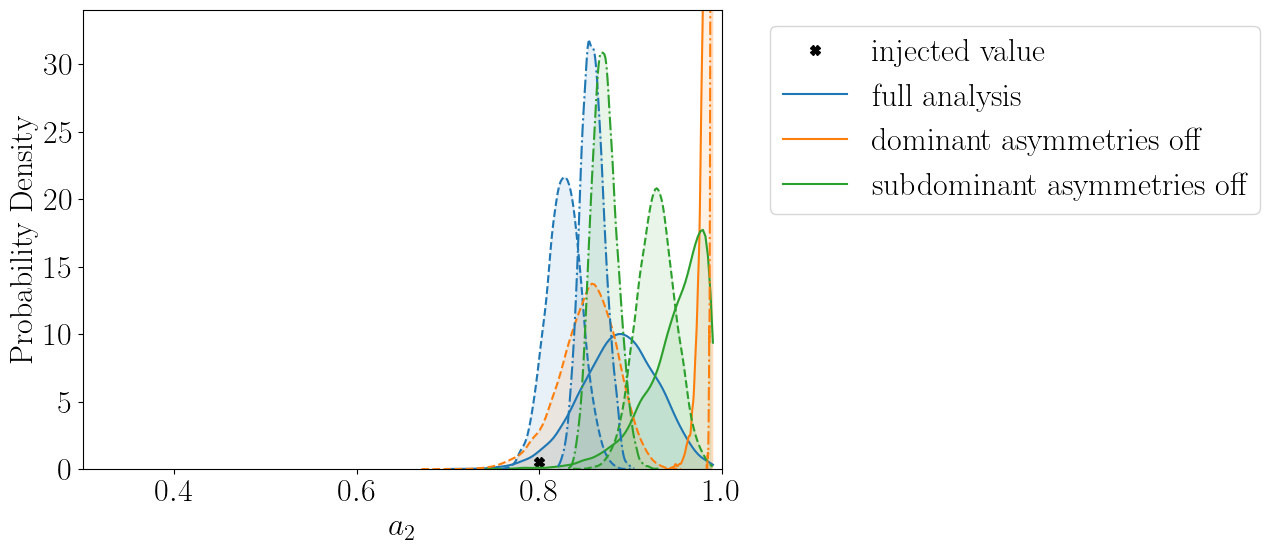

In [70]:
plt.figure(figsize=(8,6))  

plt.plot(0.8, 0.5, 'X', color='black', markersize=7, label='injected value')

samples = run2_full['posterior']['content']['a_2']
label = 'full analysis'
color = 'tab:blue'
rho_p_smoothed = gaussian_kde(samples)
h, b, o = plt.hist(samples, bins=90, density=True, histtype='step', stacked=True, fill=False, linewidth=0, color=color)
hsmoothed = rho_p_smoothed(b)*len(samples)*(b[1]-b[0])
hsmoothed = hsmoothed*max(h)/max(hsmoothed) # scale to normalise kde
plt.plot(b, hsmoothed, color=color, label=label)
plt.fill_between(b, hsmoothed, where=(0 < b)&(b < max(samples)), color=color, alpha=0.1)

samples = run2_domoff['posterior']['content']['a_2']
label = 'dominant asymmetries off'
color = 'tab:orange'
rho_p_smoothed = gaussian_kde(samples)
h, b, o = plt.hist(samples, bins=90, density=True, histtype='step', stacked=True, fill=False, linewidth=0, color=color)
hsmoothed = rho_p_smoothed(b)*len(samples)*(b[1]-b[0])
hsmoothed = hsmoothed*max(h)/max(hsmoothed) # scale to normalise kde
plt.plot(b, hsmoothed, color=color, label=label)
plt.fill_between(b, hsmoothed, where=(0 < b)&(b < max(samples)), color=color, alpha=0.1)

samples = run2_suboff['posterior']['content']['a_2']
label = 'subdominant asymmetries off'
color = 'tab:green'
rho_p_smoothed = gaussian_kde(samples)
h, b, o = plt.hist(samples, bins=90, density=True, histtype='step', stacked=True, fill=False, linewidth=0, color=color)
hsmoothed = rho_p_smoothed(b)*len(samples)*(b[1]-b[0])
hsmoothed = hsmoothed*max(h)/max(hsmoothed) # scale to normalise kde
plt.plot(b, hsmoothed, color=color, label=label)
plt.fill_between(b, hsmoothed, where=(0 < b)&(b < max(samples)), color=color, alpha=0.1)


samples = run3_full['posterior']['content']['a_2']
color = 'tab:blue'
rho_p_smoothed = gaussian_kde(samples)
h, b, o = plt.hist(samples, bins=90, density=True, histtype='step', stacked=True, fill=False, linewidth=0, color=color)
hsmoothed = rho_p_smoothed(b)*len(samples)*(b[1]-b[0])
hsmoothed = hsmoothed*max(h)/max(hsmoothed) # scale to normalise kde
plt.plot(b, hsmoothed, '--', color=color)
plt.fill_between(b, hsmoothed, where=(0 < b)&(b < max(samples)), color=color, alpha=0.1)

samples = run3_domoff['posterior']['content']['a_2']
label = 'dominant asymmetries off'
color = 'tab:orange'
rho_p_smoothed = gaussian_kde(samples)
h, b, o = plt.hist(samples, bins=90, density=True, histtype='step', stacked=True, fill=False, linewidth=0, color=color)
hsmoothed = rho_p_smoothed(b)*len(samples)*(b[1]-b[0])
hsmoothed = hsmoothed*max(h)/max(hsmoothed) # scale to normalise kde
plt.plot(b, hsmoothed, '--', color=color)
plt.fill_between(b, hsmoothed, where=(0 < b)&(b < max(samples)), color=color, alpha=0.1)

samples = run3_suboff['posterior']['content']['a_2']
color = 'tab:green'
rho_p_smoothed = gaussian_kde(samples)
h, b, o = plt.hist(samples, bins=90, density=True, histtype='step', stacked=True, fill=False, linewidth=0, color=color)
hsmoothed = rho_p_smoothed(b)*len(samples)*(b[1]-b[0])
hsmoothed = hsmoothed*max(h)/max(hsmoothed) # scale to normalise kde
plt.plot(b, hsmoothed, '--', color=color)
plt.fill_between(b, hsmoothed, where=(0 < b)&(b < max(samples)), color=color, alpha=0.1)


samples = run4_full['posterior']['content']['a_2']
color = 'tab:blue'
rho_p_smoothed = gaussian_kde(samples)
h, b, o = plt.hist(samples, bins=90, density=True, histtype='step', stacked=True, fill=False, linewidth=0, color=color)
hsmoothed = rho_p_smoothed(b)*len(samples)*(b[1]-b[0])
hsmoothed = hsmoothed*max(h)/max(hsmoothed) # scale to normalise kde
plt.plot(b, hsmoothed, '-.', color=color)
plt.fill_between(b, hsmoothed, where=(0 < b)&(b < max(samples)), color=color, alpha=0.1)

samples = run4_domoff['posterior']['content']['a_2']
label = 'dominant asymmetries off'
color = 'tab:orange'
rho_p_smoothed = gaussian_kde(samples)
h, b, o = plt.hist(samples, bins=90, density=True, histtype='step', stacked=True, fill=False, linewidth=0, color=color)
hsmoothed = rho_p_smoothed(b)*len(samples)*(b[1]-b[0])
hsmoothed = hsmoothed*max(h)/max(hsmoothed) # scale to normalise kde
plt.plot(b, hsmoothed, '-.', color=color)
plt.fill_between(b, hsmoothed, where=(0 < b)&(b < max(samples)), color=color, alpha=0.1)

samples = run4_suboff['posterior']['content']['a_2']
color = 'tab:green'
rho_p_smoothed = gaussian_kde(samples)
h, b, o = plt.hist(samples, bins=90, density=True, histtype='step', stacked=True, fill=False, linewidth=0, color=color)
hsmoothed = rho_p_smoothed(b)*len(samples)*(b[1]-b[0])
hsmoothed = hsmoothed*max(h)/max(hsmoothed) # scale to normalise kde
plt.plot(b, hsmoothed, '-.', color=color)
plt.fill_between(b, hsmoothed, where=(0 < b)&(b < max(samples)), color=color, alpha=0.1)


#plt.plot(0, -10, '-', color='silver', label=r'$\theta_{\rm JN} = \pi/2$')
#plt.plot(0, -10, '--', color='silver', label=r'$\theta_{\rm JN} = \pi/3$')
#plt.plot(0, -10, '-.', color='silver', label=r'$\theta_{\rm JN} = 0$')

plt.xlim(0.3, 1)
plt.ylim(0, 34)
plt.xlabel(r'$a_2$')
plt.ylabel('Probability Density')
plt.grid(linewidth=0.0)
plt.tight_layout()
#plt.legend(frameon=False, numpoints=1)
lgd = plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', numpoints=1)
plt.savefig('figures/a_2_comparison.png', bbox_extra_artists=(lgd,), bbox_inches='tight')
plt.show()
plt.close()

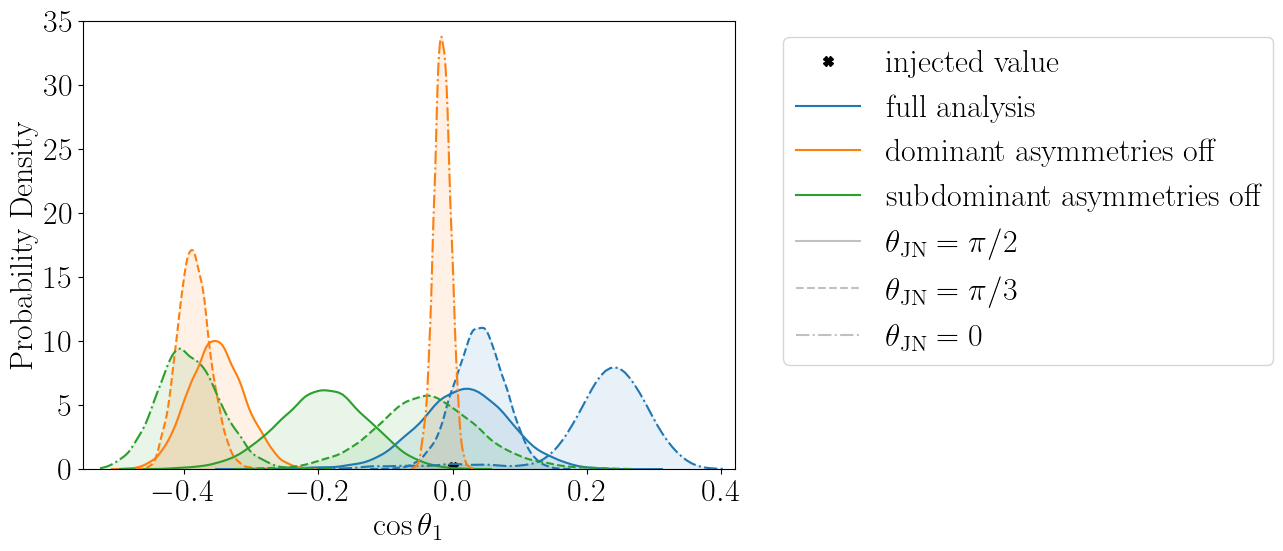

In [66]:
plt.figure(figsize=(8,6))  

plt.plot(0, 0.2, 'X', color='black', markersize=7, label='injected value')

samples = run2_full['posterior']['content']['cos_tilt_1']
label = 'full analysis'
color = 'tab:blue'
rho_p_smoothed = gaussian_kde(samples)
h, b, o = plt.hist(samples, bins=90, density=True, histtype='step', stacked=True, fill=False, linewidth=0, color=color)
hsmoothed = rho_p_smoothed(b)*len(samples)*(b[1]-b[0])
hsmoothed = hsmoothed*max(h)/max(hsmoothed) # scale to normalise kde
plt.plot(b, hsmoothed, color=color, label=label)
plt.fill_between(b, hsmoothed, where=(min(samples) < b)&(b < max(samples)), color=color, alpha=0.1)

samples = run2_domoff['posterior']['content']['cos_tilt_1']
label = 'dominant asymmetries off'
color = 'tab:orange'
rho_p_smoothed = gaussian_kde(samples)
h, b, o = plt.hist(samples, bins=90, density=True, histtype='step', stacked=True, fill=False, linewidth=0, color=color)
hsmoothed = rho_p_smoothed(b)*len(samples)*(b[1]-b[0])
hsmoothed = hsmoothed*max(h)/max(hsmoothed) # scale to normalise kde
plt.plot(b, hsmoothed, color=color, label=label)
plt.fill_between(b, hsmoothed, where=(min(samples) < b)&(b < max(samples)), color=color, alpha=0.1)

samples = run2_suboff['posterior']['content']['cos_tilt_1']
label = 'subdominant asymmetries off'
color = 'tab:green'
rho_p_smoothed = gaussian_kde(samples)
h, b, o = plt.hist(samples, bins=90, density=True, histtype='step', stacked=True, fill=False, linewidth=0, color=color)
hsmoothed = rho_p_smoothed(b)*len(samples)*(b[1]-b[0])
hsmoothed = hsmoothed*max(h)/max(hsmoothed) # scale to normalise kde
plt.plot(b, hsmoothed, color=color, label=label)
plt.fill_between(b, hsmoothed, where=(min(samples) < b)&(b < max(samples)), color=color, alpha=0.1)


samples = run3_full['posterior']['content']['cos_tilt_1']
color = 'tab:blue'
rho_p_smoothed = gaussian_kde(samples)
h, b, o = plt.hist(samples, bins=90, density=True, histtype='step', stacked=True, fill=False, linewidth=0, color=color)
hsmoothed = rho_p_smoothed(b)*len(samples)*(b[1]-b[0])
hsmoothed = hsmoothed*max(h)/max(hsmoothed) # scale to normalise kde
plt.plot(b, hsmoothed, '--', color=color)
plt.fill_between(b, hsmoothed, where=(min(samples) < b)&(b < max(samples)), color=color, alpha=0.1)

samples = run3_domoff['posterior']['content']['cos_tilt_1']
label = 'dominant asymmetries off'
color = 'tab:orange'
rho_p_smoothed = gaussian_kde(samples)
h, b, o = plt.hist(samples, bins=90, density=True, histtype='step', stacked=True, fill=False, linewidth=0, color=color)
hsmoothed = rho_p_smoothed(b)*len(samples)*(b[1]-b[0])
hsmoothed = hsmoothed*max(h)/max(hsmoothed) # scale to normalise kde
plt.plot(b, hsmoothed, '--', color=color)
plt.fill_between(b, hsmoothed, where=(min(samples) < b)&(b < max(samples)), color=color, alpha=0.1)

samples = run3_suboff['posterior']['content']['cos_tilt_1']
color = 'tab:green'
rho_p_smoothed = gaussian_kde(samples)
h, b, o = plt.hist(samples, bins=90, density=True, histtype='step', stacked=True, fill=False, linewidth=0, color=color)
hsmoothed = rho_p_smoothed(b)*len(samples)*(b[1]-b[0])
hsmoothed = hsmoothed*max(h)/max(hsmoothed) # scale to normalise kde
plt.plot(b, hsmoothed, '--', color=color)
plt.fill_between(b, hsmoothed, where=(min(samples) < b)&(b < max(samples)), color=color, alpha=0.1)


samples = run4_full['posterior']['content']['cos_tilt_1']
color = 'tab:blue'
rho_p_smoothed = gaussian_kde(samples)
h, b, o = plt.hist(samples, bins=90, density=True, histtype='step', stacked=True, fill=False, linewidth=0, color=color)
hsmoothed = rho_p_smoothed(b)*len(samples)*(b[1]-b[0])
hsmoothed = hsmoothed*max(h)/max(hsmoothed) # scale to normalise kde
plt.plot(b, hsmoothed, '-.', color=color)
plt.fill_between(b, hsmoothed, where=(min(samples) < b)&(b < max(samples)), color=color, alpha=0.1)

samples = run4_domoff['posterior']['content']['cos_tilt_1']
label = 'dominant asymmetries off'
color = 'tab:orange'
rho_p_smoothed = gaussian_kde(samples)
h, b, o = plt.hist(samples, bins=90, density=True, histtype='step', stacked=True, fill=False, linewidth=0, color=color)
hsmoothed = rho_p_smoothed(b)*len(samples)*(b[1]-b[0])
hsmoothed = hsmoothed*max(h)/max(hsmoothed) # scale to normalise kde
plt.plot(b, hsmoothed, '-.', color=color)
plt.fill_between(b, hsmoothed, where=(min(samples) < b)&(b < max(samples)), color=color, alpha=0.1)

samples = run4_suboff['posterior']['content']['cos_tilt_1']
color = 'tab:green'
rho_p_smoothed = gaussian_kde(samples)
h, b, o = plt.hist(samples, bins=90, density=True, histtype='step', stacked=True, fill=False, linewidth=0, color=color)
hsmoothed = rho_p_smoothed(b)*len(samples)*(b[1]-b[0])
hsmoothed = hsmoothed*max(h)/max(hsmoothed) # scale to normalise kde
plt.plot(b, hsmoothed, '-.', color=color)
plt.fill_between(b, hsmoothed, where=(min(samples) < b)&(b < max(samples)), color=color, alpha=0.1)


plt.plot(0, -10, '-', color='silver', label=r'$\theta_{\rm JN} = \pi/2$')
plt.plot(0, -10, '--', color='silver', label=r'$\theta_{\rm JN} = \pi/3$')
plt.plot(0, -10, '-.', color='silver', label=r'$\theta_{\rm JN} = 0$')

plt.xlim(-0.55, 0.42)
plt.ylim(0, 35)
plt.xlabel(r'$\cos\theta_1$')
plt.ylabel('Probability Density')
plt.grid(linewidth=0.0)
plt.tight_layout()
#plt.legend(frameon=False, numpoints=1)
lgd = plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', numpoints=1)
plt.savefig('figures/cos_tilt_1_comparison.png', bbox_extra_artists=(lgd,), bbox_inches='tight')
plt.show()
plt.close()

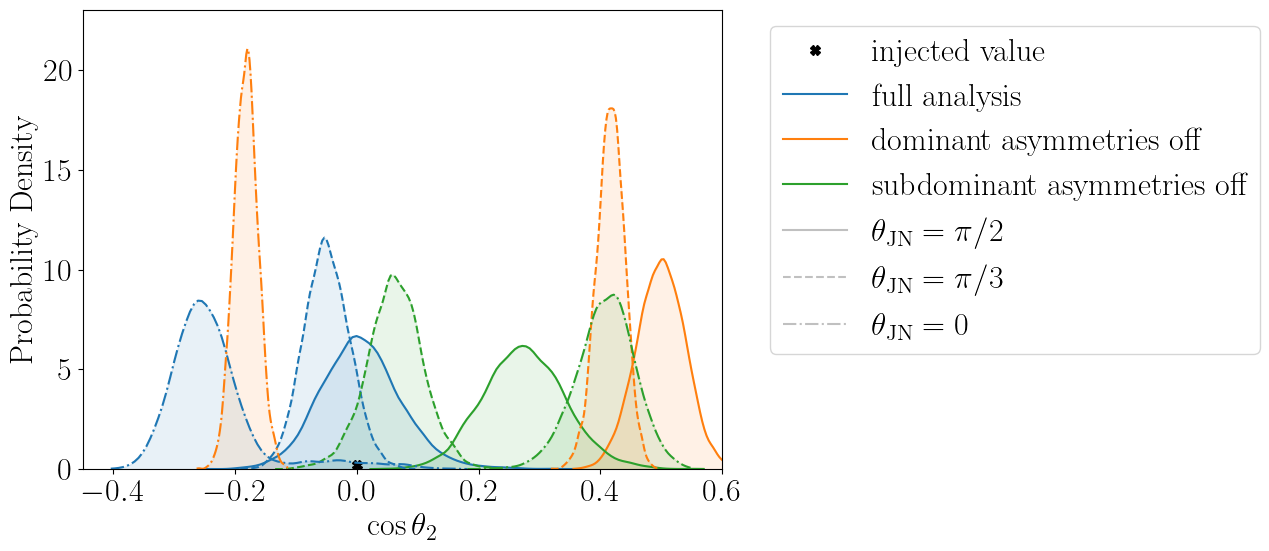

In [69]:
plt.figure(figsize=(8,6))  

plt.plot(0, 0.2, 'X', color='black', markersize=7, label='injected value')

samples = run2_full['posterior']['content']['cos_tilt_2']
label = 'full analysis'
color = 'tab:blue'
rho_p_smoothed = gaussian_kde(samples)
h, b, o = plt.hist(samples, bins=90, density=True, histtype='step', stacked=True, fill=False, linewidth=0, color=color)
hsmoothed = rho_p_smoothed(b)*len(samples)*(b[1]-b[0])
hsmoothed = hsmoothed*max(h)/max(hsmoothed) # scale to normalise kde
plt.plot(b, hsmoothed, color=color, label=label)
plt.fill_between(b, hsmoothed, where=(min(samples) < b)&(b < max(samples)), color=color, alpha=0.1)

samples = run2_domoff['posterior']['content']['cos_tilt_2']
label = 'dominant asymmetries off'
color = 'tab:orange'
rho_p_smoothed = gaussian_kde(samples)
h, b, o = plt.hist(samples, bins=90, density=True, histtype='step', stacked=True, fill=False, linewidth=0, color=color)
hsmoothed = rho_p_smoothed(b)*len(samples)*(b[1]-b[0])
hsmoothed = hsmoothed*max(h)/max(hsmoothed) # scale to normalise kde
plt.plot(b, hsmoothed, color=color, label=label)
plt.fill_between(b, hsmoothed, where=(min(samples) < b)&(b < max(samples)), color=color, alpha=0.1)

samples = run2_suboff['posterior']['content']['cos_tilt_2']
label = 'subdominant asymmetries off'
color = 'tab:green'
rho_p_smoothed = gaussian_kde(samples)
h, b, o = plt.hist(samples, bins=90, density=True, histtype='step', stacked=True, fill=False, linewidth=0, color=color)
hsmoothed = rho_p_smoothed(b)*len(samples)*(b[1]-b[0])
hsmoothed = hsmoothed*max(h)/max(hsmoothed) # scale to normalise kde
plt.plot(b, hsmoothed, color=color, label=label)
plt.fill_between(b, hsmoothed, where=(min(samples) < b)&(b < max(samples)), color=color, alpha=0.1)


samples = run3_full['posterior']['content']['cos_tilt_2']
color = 'tab:blue'
rho_p_smoothed = gaussian_kde(samples)
h, b, o = plt.hist(samples, bins=90, density=True, histtype='step', stacked=True, fill=False, linewidth=0, color=color)
hsmoothed = rho_p_smoothed(b)*len(samples)*(b[1]-b[0])
hsmoothed = hsmoothed*max(h)/max(hsmoothed) # scale to normalise kde
plt.plot(b, hsmoothed, '--', color=color)
plt.fill_between(b, hsmoothed, where=(min(samples) < b)&(b < max(samples)), color=color, alpha=0.1)

samples = run3_domoff['posterior']['content']['cos_tilt_2']
label = 'dominant asymmetries off'
color = 'tab:orange'
rho_p_smoothed = gaussian_kde(samples)
h, b, o = plt.hist(samples, bins=90, density=True, histtype='step', stacked=True, fill=False, linewidth=0, color=color)
hsmoothed = rho_p_smoothed(b)*len(samples)*(b[1]-b[0])
hsmoothed = hsmoothed*max(h)/max(hsmoothed) # scale to normalise kde
plt.plot(b, hsmoothed, '--', color=color)
plt.fill_between(b, hsmoothed, where=(min(samples) < b)&(b < max(samples)), color=color, alpha=0.1)

samples = run3_suboff['posterior']['content']['cos_tilt_2']
color = 'tab:green'
rho_p_smoothed = gaussian_kde(samples)
h, b, o = plt.hist(samples, bins=90, density=True, histtype='step', stacked=True, fill=False, linewidth=0, color=color)
hsmoothed = rho_p_smoothed(b)*len(samples)*(b[1]-b[0])
hsmoothed = hsmoothed*max(h)/max(hsmoothed) # scale to normalise kde
plt.plot(b, hsmoothed, '--', color=color)
plt.fill_between(b, hsmoothed, where=(min(samples) < b)&(b < max(samples)), color=color, alpha=0.1)


samples = run4_full['posterior']['content']['cos_tilt_2']
color = 'tab:blue'
rho_p_smoothed = gaussian_kde(samples)
h, b, o = plt.hist(samples, bins=90, density=True, histtype='step', stacked=True, fill=False, linewidth=0, color=color)
hsmoothed = rho_p_smoothed(b)*len(samples)*(b[1]-b[0])
hsmoothed = hsmoothed*max(h)/max(hsmoothed) # scale to normalise kde
plt.plot(b, hsmoothed, '-.', color=color)
plt.fill_between(b, hsmoothed, where=(min(samples) < b)&(b < max(samples)), color=color, alpha=0.1)

samples = run4_domoff['posterior']['content']['cos_tilt_2']
label = 'dominant asymmetries off'
color = 'tab:orange'
rho_p_smoothed = gaussian_kde(samples)
h, b, o = plt.hist(samples, bins=90, density=True, histtype='step', stacked=True, fill=False, linewidth=0, color=color)
hsmoothed = rho_p_smoothed(b)*len(samples)*(b[1]-b[0])
hsmoothed = hsmoothed*max(h)/max(hsmoothed) # scale to normalise kde
plt.plot(b, hsmoothed, '-.', color=color)
plt.fill_between(b, hsmoothed, where=(min(samples) < b)&(b < max(samples)), color=color, alpha=0.1)

samples = run4_suboff['posterior']['content']['cos_tilt_2']
color = 'tab:green'
rho_p_smoothed = gaussian_kde(samples)
h, b, o = plt.hist(samples, bins=90, density=True, histtype='step', stacked=True, fill=False, linewidth=0, color=color)
hsmoothed = rho_p_smoothed(b)*len(samples)*(b[1]-b[0])
hsmoothed = hsmoothed*max(h)/max(hsmoothed) # scale to normalise kde
plt.plot(b, hsmoothed, '-.', color=color)
plt.fill_between(b, hsmoothed, where=(min(samples) < b)&(b < max(samples)), color=color, alpha=0.1)


plt.plot(0, -10, '-', color='silver', label=r'$\theta_{\rm JN} = \pi/2$')
plt.plot(0, -10, '--', color='silver', label=r'$\theta_{\rm JN} = \pi/3$')
plt.plot(0, -10, '-.', color='silver', label=r'$\theta_{\rm JN} = 0$')

plt.xlim(-0.45, 0.6)
plt.ylim(0, 23)
plt.xlabel(r'$\cos\theta_2$')
plt.ylabel('Probability Density')
plt.grid(linewidth=0.0)
plt.tight_layout()
#plt.legend(frameon=False, numpoints=1)
lgd = plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', numpoints=1)
plt.savefig('figures/cos_tilt_2_comparison.png', bbox_extra_artists=(lgd,), bbox_inches='tight')
plt.show()
plt.close()

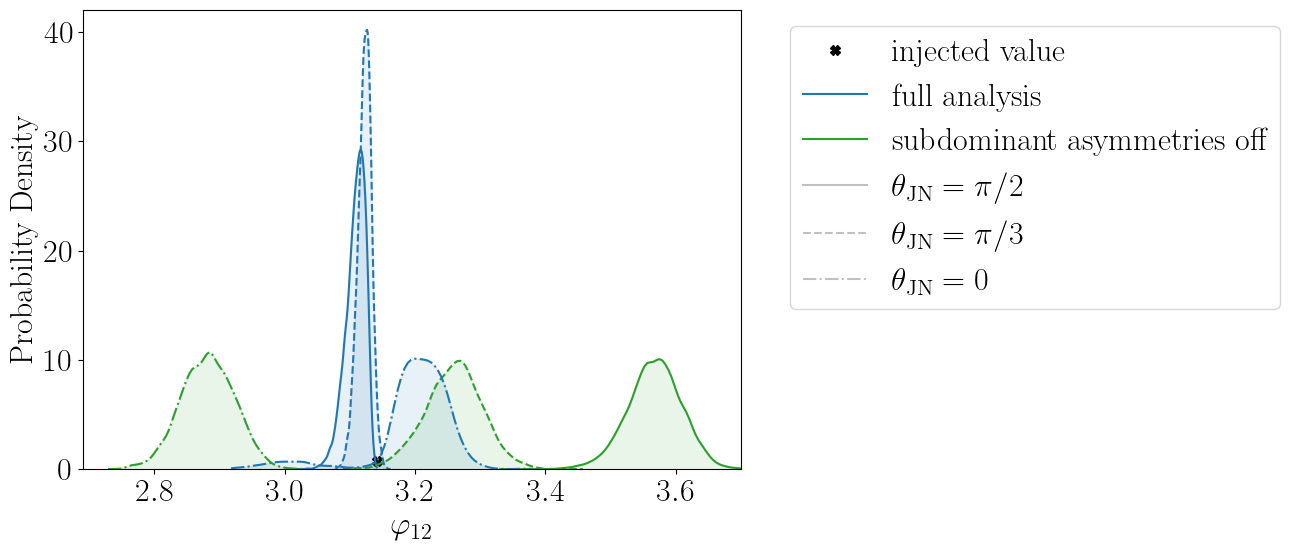

In [28]:
plt.figure(figsize=(8,6))  

plt.plot(np.pi, 0.7, 'X', color='black', markersize=7, label='injected value')

samples = run2_full['posterior']['content']['phi_12']
label = 'full analysis'
color = 'tab:blue'
rho_p_smoothed = gaussian_kde(samples)
h, b, o = plt.hist(samples, bins=90, density=True, histtype='step', stacked=True, fill=False, linewidth=0, color=color)
hsmoothed = rho_p_smoothed(b)*len(samples)*(b[1]-b[0])
hsmoothed = hsmoothed*max(h)/max(hsmoothed) # scale to normalise kde
plt.plot(b, hsmoothed, color=color, label=label)
plt.fill_between(b, hsmoothed, where=(min(samples) < b)&(b < max(samples)), color=color, alpha=0.1)

samples = run2_suboff['posterior']['content']['phi_12']
label = 'subdominant asymmetries off'
color = 'tab:green'
rho_p_smoothed = gaussian_kde(samples)
h, b, o = plt.hist(samples, bins=90, density=True, histtype='step', stacked=True, fill=False, linewidth=0, color=color)
hsmoothed = rho_p_smoothed(b)*len(samples)*(b[1]-b[0])
hsmoothed = hsmoothed*max(h)/max(hsmoothed) # scale to normalise kde
plt.plot(b, hsmoothed, color=color, label=label)
plt.fill_between(b, hsmoothed, where=(min(samples) < b)&(b < max(samples)), color=color, alpha=0.1)


samples = run3_full['posterior']['content']['phi_12']
color = 'tab:blue'
rho_p_smoothed = gaussian_kde(samples)
h, b, o = plt.hist(samples, bins=90, density=True, histtype='step', stacked=True, fill=False, linewidth=0, color=color)
hsmoothed = rho_p_smoothed(b)*len(samples)*(b[1]-b[0])
hsmoothed = hsmoothed*max(h)/max(hsmoothed) # scale to normalise kde
plt.plot(b, hsmoothed, '--', color=color)
plt.fill_between(b, hsmoothed, where=(min(samples) < b)&(b < max(samples)), color=color, alpha=0.1)

samples = run3_suboff['posterior']['content']['phi_12']
color = 'tab:green'
rho_p_smoothed = gaussian_kde(samples)
h, b, o = plt.hist(samples, bins=90, density=True, histtype='step', stacked=True, fill=False, linewidth=0, color=color)
hsmoothed = rho_p_smoothed(b)*len(samples)*(b[1]-b[0])
hsmoothed = hsmoothed*max(h)/max(hsmoothed) # scale to normalise kde
plt.plot(b, hsmoothed, '--', color=color)
plt.fill_between(b, hsmoothed, where=(min(samples) < b)&(b < max(samples)), color=color, alpha=0.1)


samples = run4_full['posterior']['content']['phi_12']
color = 'tab:blue'
rho_p_smoothed = gaussian_kde(samples)
h, b, o = plt.hist(samples, bins=90, density=True, histtype='step', stacked=True, fill=False, linewidth=0, color=color)
hsmoothed = rho_p_smoothed(b)*len(samples)*(b[1]-b[0])
hsmoothed = hsmoothed*max(h)/max(hsmoothed) # scale to normalise kde
plt.plot(b, hsmoothed, '-.', color=color)
plt.fill_between(b, hsmoothed, where=(min(samples) < b)&(b < max(samples)), color=color, alpha=0.1)

samples = run4_suboff['posterior']['content']['phi_12']
color = 'tab:green'
rho_p_smoothed = gaussian_kde(samples)
h, b, o = plt.hist(samples, bins=90, density=True, histtype='step', stacked=True, fill=False, linewidth=0, color=color)
hsmoothed = rho_p_smoothed(b)*len(samples)*(b[1]-b[0])
hsmoothed = hsmoothed*max(h)/max(hsmoothed) # scale to normalise kde
plt.plot(b, hsmoothed, '-.', color=color)
plt.fill_between(b, hsmoothed, where=(min(samples) < b)&(b < max(samples)), color=color, alpha=0.1)


plt.plot(0, -10, '-', color='silver', label=r'$\theta_{\rm JN} = \pi/2$')
plt.plot(0, -10, '--', color='silver', label=r'$\theta_{\rm JN} = \pi/3$')
plt.plot(0, -10, '-.', color='silver', label=r'$\theta_{\rm JN} = 0$')

plt.xlim(2.69, 3.7)
plt.ylim(0, 42)
plt.xlabel(r'$\varphi_{12}$')
plt.ylabel('Probability Density')
plt.grid(linewidth=0.0)
plt.tight_layout()
#plt.legend(frameon=False, numpoints=1)
lgd = plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', numpoints=1)
plt.savefig('figures/phi_12_comparison.png', bbox_extra_artists=(lgd,), bbox_inches='tight')
plt.show()
plt.close()

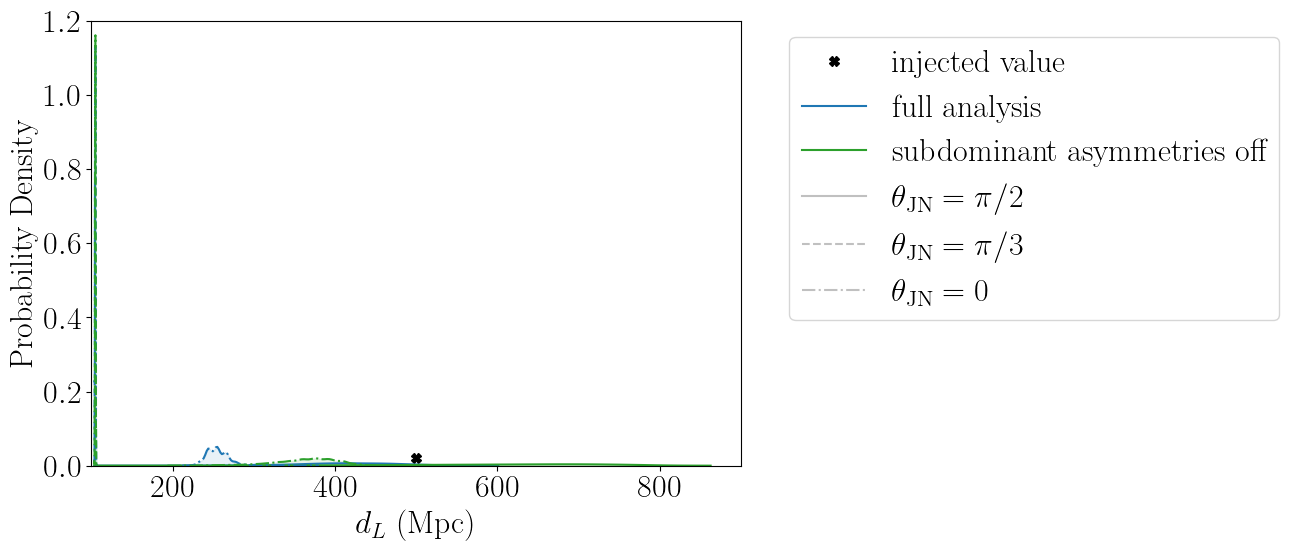

In [40]:
plt.figure(figsize=(8,6))  

plt.plot(500, 0.02, 'X', color='black', markersize=7, label='injected value')

samples = run2_full['posterior']['content']['luminosity_distance']
label = 'full analysis'
color = 'tab:blue'
rho_p_smoothed = gaussian_kde(samples)
h, b, o = plt.hist(samples, bins=90, density=True, histtype='step', stacked=True, fill=False, linewidth=0, color=color)
hsmoothed = rho_p_smoothed(b)*len(samples)*(b[1]-b[0])
hsmoothed = hsmoothed*max(h)/max(hsmoothed) # scale to normalise kde
plt.plot(b, hsmoothed, color=color, label=label)
plt.fill_between(b, hsmoothed, where=(min(samples) < b)&(b < max(samples)), color=color, alpha=0.1)

samples = run2_suboff['posterior']['content']['luminosity_distance']
label = 'subdominant asymmetries off'
color = 'tab:green'
rho_p_smoothed = gaussian_kde(samples)
h, b, o = plt.hist(samples, bins=90, density=True, histtype='step', stacked=True, fill=False, linewidth=0, color=color)
hsmoothed = rho_p_smoothed(b)*len(samples)*(b[1]-b[0])
hsmoothed = hsmoothed*max(h)/max(hsmoothed) # scale to normalise kde
plt.plot(b, hsmoothed, color=color, label=label)
plt.fill_between(b, hsmoothed, where=(min(samples) < b)&(b < max(samples)), color=color, alpha=0.1)


samples = run3_full['posterior']['content']['luminosity_distance']
color = 'tab:blue'
rho_p_smoothed = gaussian_kde(samples)
h, b, o = plt.hist(samples, bins=90, density=True, histtype='step', stacked=True, fill=False, linewidth=0, color=color)
hsmoothed = rho_p_smoothed(b)*len(samples)*(b[1]-b[0])
hsmoothed = hsmoothed*max(h)/max(hsmoothed) # scale to normalise kde
plt.plot(b, hsmoothed, '--', color=color)
plt.fill_between(b, hsmoothed, where=(min(samples) < b)&(b < max(samples)), color=color, alpha=0.1)

samples = run3_suboff['posterior']['content']['luminosity_distance']
color = 'tab:green'
rho_p_smoothed = gaussian_kde(samples)
h, b, o = plt.hist(samples, bins=90, density=True, histtype='step', stacked=True, fill=False, linewidth=0, color=color)
hsmoothed = rho_p_smoothed(b)*len(samples)*(b[1]-b[0])
hsmoothed = hsmoothed*max(h)/max(hsmoothed) # scale to normalise kde
plt.plot(b, hsmoothed, '--', color=color)
plt.fill_between(b, hsmoothed, where=(min(samples) < b)&(b < max(samples)), color=color, alpha=0.1)


samples = run4_full['posterior']['content']['luminosity_distance']
color = 'tab:blue'
rho_p_smoothed = gaussian_kde(samples)
h, b, o = plt.hist(samples, bins=90, density=True, histtype='step', stacked=True, fill=False, linewidth=0, color=color)
hsmoothed = rho_p_smoothed(b)*len(samples)*(b[1]-b[0])
hsmoothed = hsmoothed*max(h)/max(hsmoothed) # scale to normalise kde
plt.plot(b, hsmoothed, '-.', color=color)
plt.fill_between(b, hsmoothed, where=(min(samples) < b)&(b < max(samples)), color=color, alpha=0.1)

samples = run4_suboff['posterior']['content']['luminosity_distance']
color = 'tab:green'
rho_p_smoothed = gaussian_kde(samples)
h, b, o = plt.hist(samples, bins=90, density=True, histtype='step', stacked=True, fill=False, linewidth=0, color=color)
hsmoothed = rho_p_smoothed(b)*len(samples)*(b[1]-b[0])
hsmoothed = hsmoothed*max(h)/max(hsmoothed) # scale to normalise kde
plt.plot(b, hsmoothed, '-.', color=color)
plt.fill_between(b, hsmoothed, where=(min(samples) < b)&(b < max(samples)), color=color, alpha=0.1)

plt.plot(0, -10, '-', color='silver', label=r'$\theta_{\rm JN} = \pi/2$')
plt.plot(0, -10, '--', color='silver', label=r'$\theta_{\rm JN} = \pi/3$')
plt.plot(0, -10, '-.', color='silver', label=r'$\theta_{\rm JN} = 0$')

plt.xlim(100, 900)
plt.ylim(0, 1.2)
plt.xlabel(r'$d_{L}$ (Mpc)')
plt.ylabel('Probability Density')
plt.grid(linewidth=0.0)
plt.tight_layout()
#plt.legend(frameon=False, numpoints=1)
lgd = plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', numpoints=1)
plt.savefig('figures/luminosity_distance_comparison.png', bbox_extra_artists=(lgd,), bbox_inches='tight')
plt.show()
plt.close()

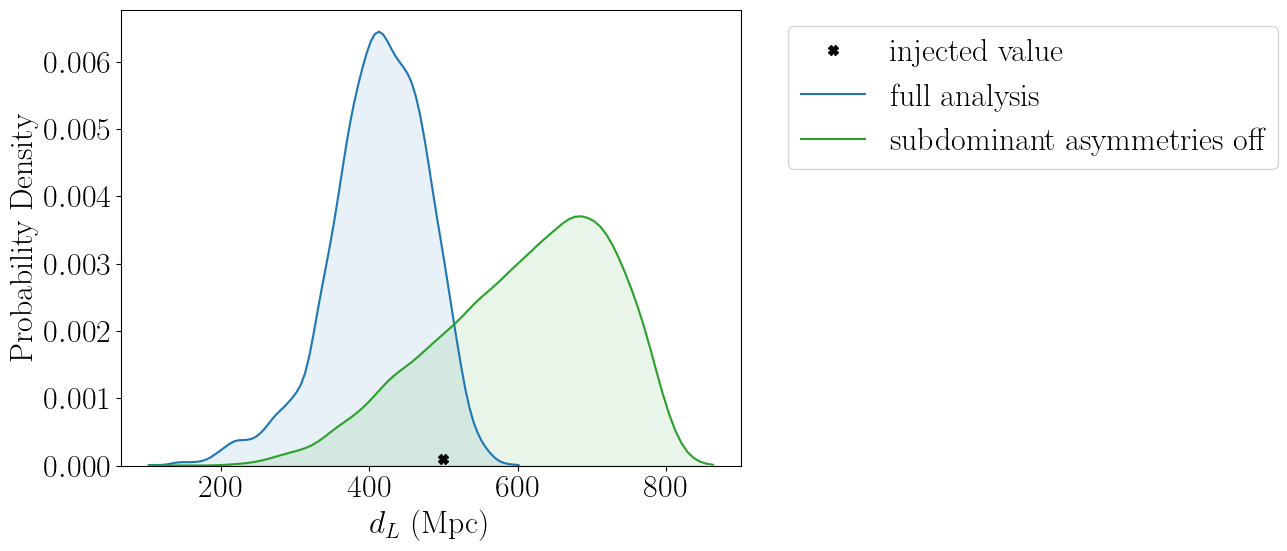

In [71]:
plt.figure(figsize=(8,6))  

plt.plot(500, 0.0001, 'X', color='black', markersize=7, label='injected value')

samples = run2_full['posterior']['content']['luminosity_distance']
label = 'full analysis'
color = 'tab:blue'
rho_p_smoothed = gaussian_kde(samples)
h, b, o = plt.hist(samples, bins=90, density=True, histtype='step', stacked=True, fill=False, linewidth=0, color=color)
hsmoothed = rho_p_smoothed(b)*len(samples)*(b[1]-b[0])
hsmoothed = hsmoothed*max(h)/max(hsmoothed) # scale to normalise kde
plt.plot(b, hsmoothed, color=color, label=label)
plt.fill_between(b, hsmoothed, where=(min(samples) < b)&(b < max(samples)), color=color, alpha=0.1)

samples = run2_suboff['posterior']['content']['luminosity_distance']
label = 'subdominant asymmetries off'
color = 'tab:green'
rho_p_smoothed = gaussian_kde(samples)
h, b, o = plt.hist(samples, bins=90, density=True, histtype='step', stacked=True, fill=False, linewidth=0, color=color)
hsmoothed = rho_p_smoothed(b)*len(samples)*(b[1]-b[0])
hsmoothed = hsmoothed*max(h)/max(hsmoothed) # scale to normalise kde
plt.plot(b, hsmoothed, color=color, label=label)
plt.fill_between(b, hsmoothed, where=(min(samples) < b)&(b < max(samples)), color=color, alpha=0.1)


#plt.xlim(100, 900)
#plt.ylim(0, 1.2)
plt.xlabel(r'$d_{L}$ (Mpc)')
plt.ylabel('Probability Density')
plt.grid(linewidth=0.0)
plt.tight_layout()
#plt.legend(frameon=False, numpoints=1)
lgd = plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', numpoints=1)
plt.savefig('figures/luminosity_distance_comparison.png', bbox_extra_artists=(lgd,), bbox_inches='tight')
plt.show()
plt.close()

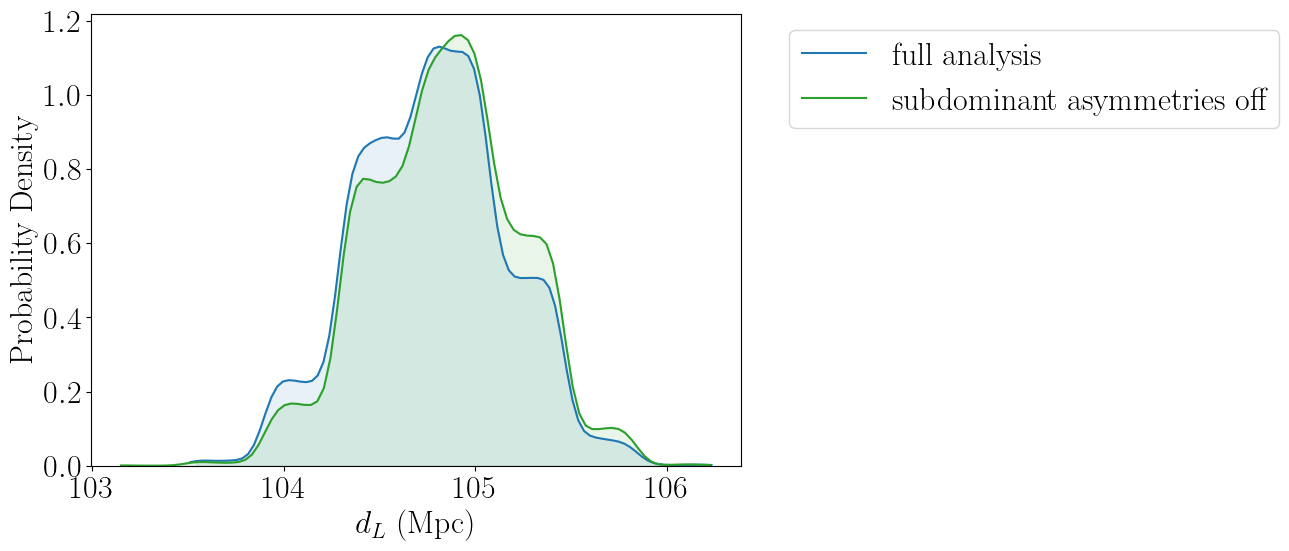

In [73]:
plt.figure(figsize=(8,6))  

#plt.plot(500, 0.0001, 'X', color='black', markersize=7, label='injected value')

samples = run3_full['posterior']['content']['luminosity_distance']
label = 'full analysis'
color = 'tab:blue'
rho_p_smoothed = gaussian_kde(samples)
h, b, o = plt.hist(samples, bins=90, density=True, histtype='step', stacked=True, fill=False, linewidth=0, color=color)
hsmoothed = rho_p_smoothed(b)*len(samples)*(b[1]-b[0])
hsmoothed = hsmoothed*max(h)/max(hsmoothed) # scale to normalise kde
plt.plot(b, hsmoothed, color=color, label=label)
plt.fill_between(b, hsmoothed, where=(min(samples) < b)&(b < max(samples)), color=color, alpha=0.1)

samples = run3_suboff['posterior']['content']['luminosity_distance']
label = 'subdominant asymmetries off'
color = 'tab:green'
rho_p_smoothed = gaussian_kde(samples)
h, b, o = plt.hist(samples, bins=90, density=True, histtype='step', stacked=True, fill=False, linewidth=0, color=color)
hsmoothed = rho_p_smoothed(b)*len(samples)*(b[1]-b[0])
hsmoothed = hsmoothed*max(h)/max(hsmoothed) # scale to normalise kde
plt.plot(b, hsmoothed, color=color, label=label)
plt.fill_between(b, hsmoothed, where=(min(samples) < b)&(b < max(samples)), color=color, alpha=0.1)


#plt.xlim(100, 900)
#plt.ylim(0, 1.2)
plt.xlabel(r'$d_{L}$ (Mpc)')
plt.ylabel('Probability Density')
plt.grid(linewidth=0.0)
plt.tight_layout()
#plt.legend(frameon=False, numpoints=1)
lgd = plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', numpoints=1)
#plt.savefig('figures/luminosity_distance_comparison.png', bbox_extra_artists=(lgd,), bbox_inches='tight')
plt.show()
plt.close()

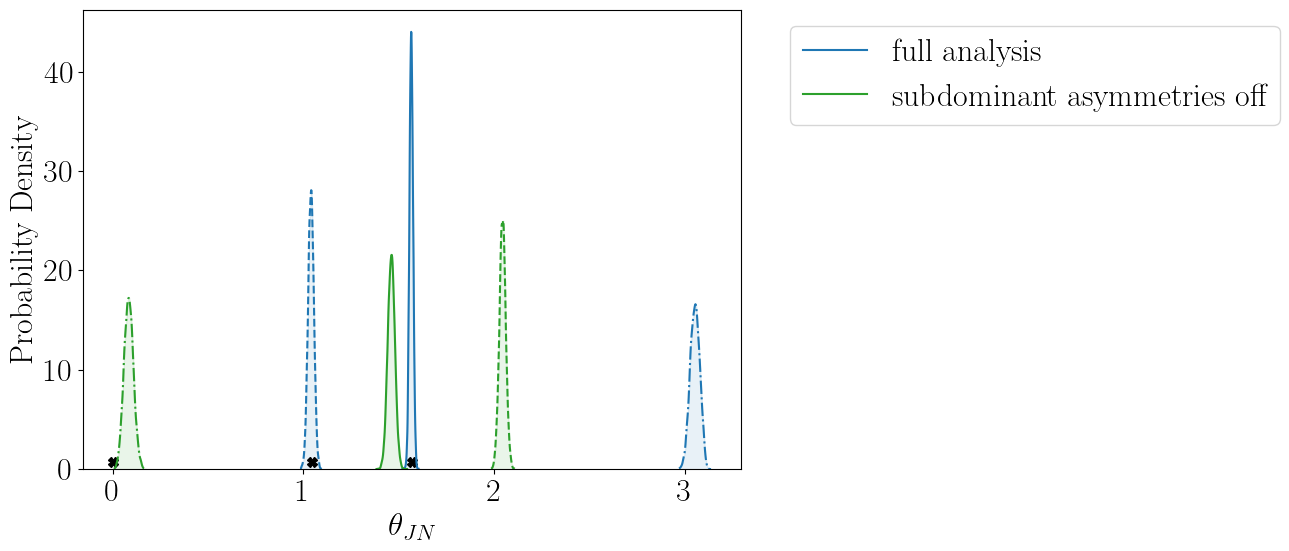

In [34]:
plt.figure(figsize=(8,6))  

plt.plot(np.pi/2., 0.7, 'X', color='black', markersize=7)
plt.plot(np.pi/3., 0.7, 'X', color='black', markersize=7)
plt.plot(0, 0.7, 'X', color='black', markersize=7)


samples = run2_full['posterior']['content']['theta_jn']
label = 'full analysis'
color = 'tab:blue'
rho_p_smoothed = gaussian_kde(samples)
h, b, o = plt.hist(samples, bins=90, density=True, histtype='step', stacked=True, fill=False, linewidth=0, color=color)
hsmoothed = rho_p_smoothed(b)*len(samples)*(b[1]-b[0])
hsmoothed = hsmoothed*max(h)/max(hsmoothed) # scale to normalise kde
plt.plot(b, hsmoothed, color=color, label=label)
plt.fill_between(b, hsmoothed, where=(0 < b)&(b < max(samples)), color=color, alpha=0.1)

samples = run2_suboff['posterior']['content']['theta_jn']
label = 'subdominant asymmetries off'
color = 'tab:green'
rho_p_smoothed = gaussian_kde(samples)
h, b, o = plt.hist(samples, bins=90, density=True, histtype='step', stacked=True, fill=False, linewidth=0, color=color)
hsmoothed = rho_p_smoothed(b)*len(samples)*(b[1]-b[0])
hsmoothed = hsmoothed*max(h)/max(hsmoothed) # scale to normalise kde
plt.plot(b, hsmoothed, color=color, label=label)
plt.fill_between(b, hsmoothed, where=(0 < b)&(b < max(samples)), color=color, alpha=0.1)


samples = run3_full['posterior']['content']['theta_jn']
color = 'tab:blue'
rho_p_smoothed = gaussian_kde(samples)
h, b, o = plt.hist(samples, bins=90, density=True, histtype='step', stacked=True, fill=False, linewidth=0, color=color)
hsmoothed = rho_p_smoothed(b)*len(samples)*(b[1]-b[0])
hsmoothed = hsmoothed*max(h)/max(hsmoothed) # scale to normalise kde
plt.plot(b, hsmoothed, '--', color=color)
plt.fill_between(b, hsmoothed, where=(0 < b)&(b < max(samples)), color=color, alpha=0.1)

samples = run3_suboff['posterior']['content']['theta_jn']
color = 'tab:green'
rho_p_smoothed = gaussian_kde(samples)
h, b, o = plt.hist(samples, bins=90, density=True, histtype='step', stacked=True, fill=False, linewidth=0, color=color)
hsmoothed = rho_p_smoothed(b)*len(samples)*(b[1]-b[0])
hsmoothed = hsmoothed*max(h)/max(hsmoothed) # scale to normalise kde
plt.plot(b, hsmoothed, '--', color=color)
plt.fill_between(b, hsmoothed, where=(0 < b)&(b < max(samples)), color=color, alpha=0.1)


samples = run4_full['posterior']['content']['theta_jn']
color = 'tab:blue'
rho_p_smoothed = gaussian_kde(samples)
h, b, o = plt.hist(samples, bins=90, density=True, histtype='step', stacked=True, fill=False, linewidth=0, color=color)
hsmoothed = rho_p_smoothed(b)*len(samples)*(b[1]-b[0])
hsmoothed = hsmoothed*max(h)/max(hsmoothed) # scale to normalise kde
plt.plot(b, hsmoothed, '-.', color=color)
plt.fill_between(b, hsmoothed, where=(0 < b)&(b < max(samples)), color=color, alpha=0.1)

samples = run4_suboff['posterior']['content']['theta_jn']
color = 'tab:green'
rho_p_smoothed = gaussian_kde(samples)
h, b, o = plt.hist(samples, bins=90, density=True, histtype='step', stacked=True, fill=False, linewidth=0, color=color)
hsmoothed = rho_p_smoothed(b)*len(samples)*(b[1]-b[0])
hsmoothed = hsmoothed*max(h)/max(hsmoothed) # scale to normalise kde
plt.plot(b, hsmoothed, '-.', color=color)
plt.fill_between(b, hsmoothed, where=(0 < b)&(b < max(samples)), color=color, alpha=0.1)

#plt.plot(0, -10, '-', color='silver', label=r'$\theta_{\rm JN} = \pi/2$')
#plt.plot(0, -10, '--', color='silver', label=r'$\theta_{\rm JN} = \pi/3$')
#plt.plot(0, -10, '-.', color='silver', label=r'$\theta_{\rm JN} = 0$')

#plt.xlim(-0.05, 2.2)
#plt.ylim(0, 47)
plt.xlabel(r'$\theta_{JN}$')
plt.ylabel('Probability Density')
plt.grid(linewidth=0.0)
plt.tight_layout()
#plt.legend(frameon=False, numpoints=1)
lgd = plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', numpoints=1)
plt.savefig('figures/inclination_angle.png')
plt.show()
plt.close()